# **Silver Price Prediction Using Machine Learning and Time-Series Analysis**

Data Fetching using `yfinance` for real time data

## **Libraries**

In [1]:
import os
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

warnings.filterwarnings('ignore')

## **Data Fetching**

**Daily Silver Prices for last 1 Year**

In [2]:
ticker = "SI=F"

silver = yf.Ticker(ticker)

print("Fetching Daily prices from last year\n")
daily_data = silver.history(period='2y', interval='1d')

print("Daily Data (Last 1 Year)")
daily_data.tail()

Fetching Daily prices from last year

Daily Data (Last 1 Year)


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-04-07 00:00:00-04:00,71.894997,71.894997,70.000000,71.825996,91,0.0,0.0
2026-04-08 00:00:00-04:00,76.169998,77.449997,75.223999,75.223999,34,0.0,0.0
2026-04-09 00:00:00-04:00,73.779999,76.277000,73.779999,76.277000,4,0.0,0.0
2026-04-10 00:00:00-04:00,75.305000,76.650002,75.305000,76.323997,4,0.0,0.0
2026-04-13 00:00:00-04:00,75.654999,76.184998,75.654999,75.925003,1031,0.0,0.0


**Last 24 Months Data**

In [3]:
monthly_data = silver.history(period="24mo", interval="1mo")

print("\nMonthly Data (Last 24 Months)")
monthly_data.tail()


Monthly Data (Last 24 Months)


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-10-01 00:00:00-04:00,47.345001,53.340000,45.384998,47.993999,8909,0.0,0.0
2025-11-01 00:00:00-04:00,47.825001,56.455002,46.805000,56.445999,82280,0.0,0.0
2025-12-01 00:00:00-05:00,56.220001,79.699997,56.139999,70.134003,8656,0.0,0.0
2026-01-01 00:00:00-05:00,71.375000,121.300003,70.556000,78.290001,14816,0.0,0.0
2026-04-01 00:00:00-04:00,74.345001,77.449997,69.834999,75.925003,1246,0.0,0.0


**Converting to csv**

In [4]:
os.makedirs("data", exist_ok=True)
daily_data.to_csv("data/silver_daily_1year.csv")
monthly_data.to_csv("data/silver_monthly_24months.csv")

## **Preprocessing**

In [5]:
daily_data = pd.read_csv("data/silver_daily_1year.csv")
daily_data.tail()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
497,2026-04-07 00:00:00-04:00,71.894997,71.894997,70.000000,71.825996,91,0.0,0.0
498,2026-04-08 00:00:00-04:00,76.169998,77.449997,75.223999,75.223999,34,0.0,0.0
499,2026-04-09 00:00:00-04:00,73.779999,76.277000,73.779999,76.277000,4,0.0,0.0
500,2026-04-10 00:00:00-04:00,75.305000,76.650002,75.305000,76.323997,4,0.0,0.0
501,2026-04-13 00:00:00-04:00,75.654999,76.184998,75.654999,75.925003,1031,0.0,0.0


**Daily Data Preprocessing**

In [6]:
daily_data.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends',
       'Stock Splits'],
      dtype='object')

In [7]:
daily_data["Target"] = daily_data["Close"].shift(-1)

In [8]:
# Keeping only required data

daily_data.drop(['Stock Splits', 'Dividends'], axis=1, inplace=True)
daily_data.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Target'], dtype='object')

In [ ]:
# Date Processing

daily_data['Date'] = pd.to_datetime(daily_data['Date'], utc=True).dt.date
daily_data.tail()

,Date,Open,High,Low,Close,Volume,Target
500,2026-02-23,86.495003,87.915001,86.495003,86.523003,41,87.457001
501,2026-02-24,86.290001,87.457001,86.290001,87.457001,268,90.939003
502,2026-02-25,90.939003,90.939003,90.939003,90.939003,36156,86.998001
503,2026-02-26,88.925003,90.254997,84.980003,86.998001,36156,91.095001
504,2026-02-27,89.074997,91.150002,88.305000,91.095001,7839,NaN


**Monthly Data**

In [ ]:
monthly_data = pd.read_csv("data/silver_monthly_24months.csv")
monthly_data.tail()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
16,2025-10-01 00:00:00-04:00,47.345001,53.340000,45.384998,47.993999,8909,0.0,0.0
17,2025-11-01 00:00:00-04:00,47.825001,56.455002,46.805000,56.445999,82280,0.0,0.0
18,2025-12-01 00:00:00-05:00,56.220001,79.699997,56.139999,70.134003,8656,0.0,0.0
19,2026-01-01 00:00:00-05:00,71.375000,121.300003,70.556000,78.290001,14816,0.0,0.0
20,2026-02-27 00:00:00-05:00,89.074997,91.150002,88.305000,91.095001,7839,0.0,0.0


In [ ]:
monthly_data['Date'] = pd.to_datetime(monthly_data['Date'], utc=True).dt.date
monthly_data.tail()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
16,2025-10-01,47.345001,53.340000,45.384998,47.993999,8909,0.0,0.0
17,2025-11-01,47.825001,56.455002,46.805000,56.445999,82280,0.0,0.0
18,2025-12-01,56.220001,79.699997,56.139999,70.134003,8656,0.0,0.0
19,2026-01-01,71.375000,121.300003,70.556000,78.290001,14816,0.0,0.0
20,2026-02-27,89.074997,91.150002,88.305000,91.095001,7839,0.0,0.0


In [ ]:
# Keeping only required data

monthly_data.drop(['Stock Splits', 'Dividends'], axis=1, inplace=True)
monthly_data.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='str')

## **EDA**

#### **Daily Data**

**Line Plot**

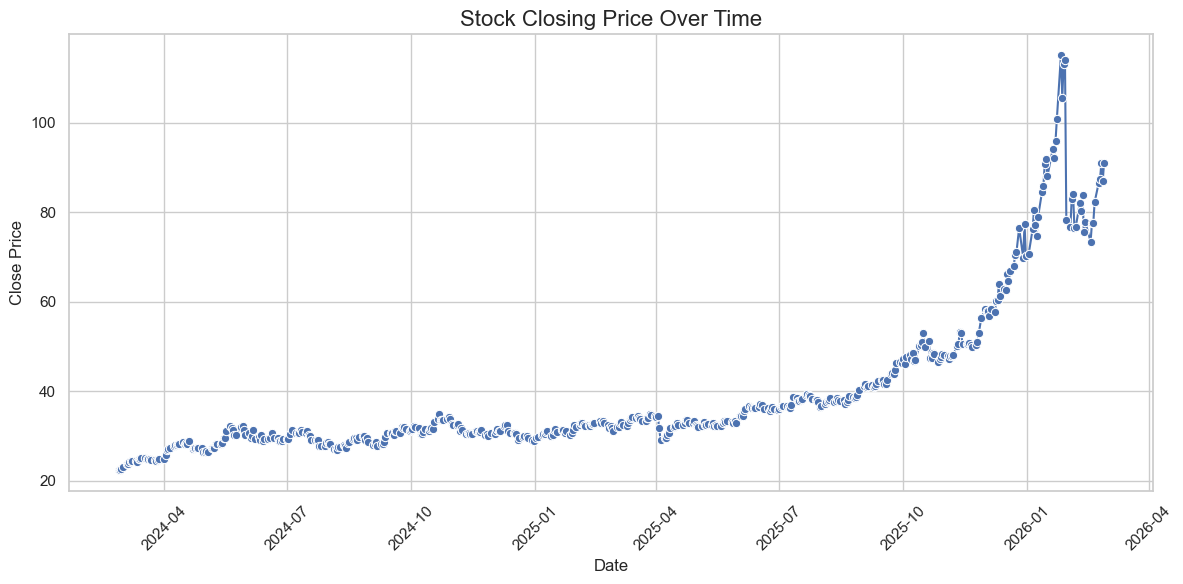

In [ ]:
daily_data['Date'] = pd.to_datetime(daily_data['Date'])

# 2. Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 3. Create the line plot
line_plot = sns.lineplot(data=daily_data, x='Date', y='Close', marker='o', color='b')

# 4. Customizing labels and title
plt.title('Stock Closing Price Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price', fontsize=12)

# Rotate dates for better readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Candle Stick Chart**

In [ ]:
import plotly.graph_objects as go

# 2. Create the Candlestick figure
fig = go.Figure(data=[go.Candlestick(
    x=daily_data['Date'],
    open=daily_data['Open'],
    high=daily_data['High'],
    low=daily_data['Low'],
    close=daily_data['Close'],
    increasing_line_color='green',
    decreasing_line_color='red'
)])

# 3. Customize layout
fig.update_layout(
    title='Stock Price Candlestick Chart (February 2026)',
    yaxis_title='Price (USD)',
    xaxis_title='Date',
    xaxis_rangeslider_visible=True,
    template='plotly_white'
)

# 4. Show the plot
fig.show()

#### **Monthly Data**

**Line Plot**

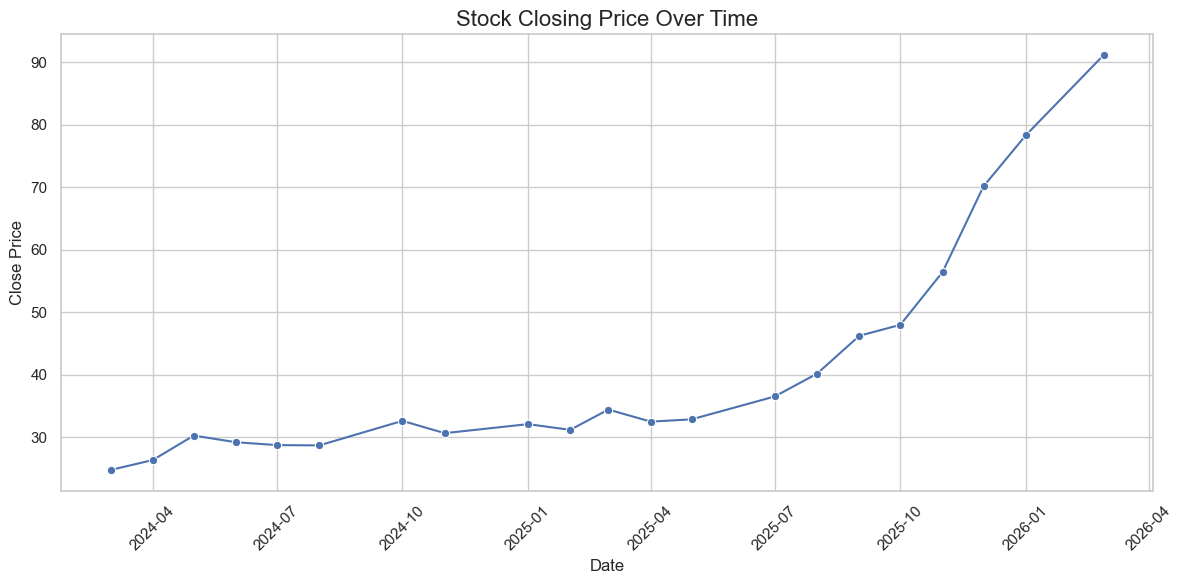

In [ ]:
monthly_data['Date'] = pd.to_datetime(monthly_data['Date'])

# 2. Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 3. Create the line plot
line_plot = sns.lineplot(data=monthly_data, x='Date', y='Close', marker='o', color='b')

# 4. Customizing labels and title
plt.title('Stock Closing Price Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price', fontsize=12)

# Rotate dates for better readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Candle Stick Chart**

In [ ]:
fig = go.Figure(data=[go.Candlestick(
    x=monthly_data['Date'],
    open=monthly_data['Open'],
    high=monthly_data['High'],
    low=monthly_data['Low'],
    close=monthly_data['Close'],
    increasing_line_color='green',
    decreasing_line_color='red'
)])

# 3. Customize layout
fig.update_layout(
    title='Stock Price Candlestick Chart',
    yaxis_title='Price (USD)',
    xaxis_title='Date',
    xaxis_rangeslider_visible=True,
    template='plotly_white'
)

# 4. Show the plot
fig.show()

## **Feature Engineering**

**Daily Data**

In [ ]:
# Price movement
daily_data["Return"] = daily_data["Close"].pct_change()

# Daily range (volatility proxy)
daily_data["Range"] = daily_data["High"] - daily_data["Low"]

# Rolling averages
daily_data["MA_7"] = daily_data["Close"].rolling(7).mean()
daily_data["MA_14"] = daily_data["Close"].rolling(14).mean()
daily_data["MA_30"] = daily_data["Close"].rolling(30).mean()

# Rolling standard deviation (volatility)
daily_data["Volatility_7"] = daily_data["Close"].rolling(7).std()
daily_data["Volatility_30"] = daily_data["Close"].rolling(30).std()

# Momentum
daily_data["Momentum_7"] = daily_data["Close"] - daily_data["Close"].shift(7)

# Lag features
daily_data["Lag_1"] = daily_data["Close"].shift(1)
daily_data["Lag_2"] = daily_data["Close"].shift(2)
daily_data["Lag_3"] = daily_data["Close"].shift(3)
daily_data["Lag_7"] = daily_data["Close"].shift(7)

In [ ]:
daily_data.tail()

,Date,Open,High,Low,Close,Volume,Target,Return,Range,MA_7,MA_14,MA_30,Volatility_7,Volatility_30,Momentum_7,Lag_1,Lag_2,Lag_3,Lag_7
500,2026-02-23,86.495003,87.915001,86.495003,86.523003,41,87.457001,0.051530,1.419998,78.674857,79.802286,87.452501,4.378015,11.897065,2.769005,82.282997,77.565002,77.509003,83.753998
501,2026-02-24,86.290001,87.457001,86.290001,87.457001,268,90.939003,0.010795,1.167000,80.376429,80.117643,87.738267,5.197290,11.786602,11.911003,86.523003,82.282997,77.565002,75.545998
502,2026-02-25,90.939003,90.939003,90.939003,90.939003,36156,86.998001,0.039814,0.000000,82.246144,80.601500,87.949234,6.361214,11.785319,13.088005,87.457001,86.523003,82.282997,77.850998
503,2026-02-26,88.925003,90.254997,84.980003,86.998001,36156,91.095001,-0.043337,5.274994,84.182001,81.349286,87.986601,5.191542,11.780298,13.551003,90.939003,87.457001,86.523003,73.446999
504,2026-02-27,89.074997,91.150002,88.305000,91.095001,7839,NaN,0.047093,2.845001,86.122858,82.375001,87.994134,4.806329,11.782277,13.585999,86.998001,90.939003,87.457001,77.509003


**Monthly Data**

In [ ]:
# Price movement
monthly_data["Return"] = monthly_data["Close"].pct_change()

# Monthly range
monthly_data["Range"] = monthly_data["High"] - monthly_data["Low"]

# Rolling averages (Quarterly (3), Half-year(6), Year)
monthly_data["MA_3"] = monthly_data["Close"].rolling(3).mean()
monthly_data["MA_6"] = monthly_data["Close"].rolling(6).mean()
monthly_data["MA_12"] = monthly_data["Close"].rolling(12).mean()

# Rolling standard deviation (Volatility)
monthly_data["Volatility_3"] = monthly_data["Close"].rolling(3).std()
monthly_data["Volatility_6"] = monthly_data["Close"].rolling(6).std()

# Momentum
monthly_data["Momentum_3"] = monthly_data["Close"] - monthly_data["Close"].shift(3)

# Lag features
monthly_data["Lag_1"] = monthly_data["Close"].shift(1)
monthly_data["Lag_2"] = monthly_data["Close"].shift(2)
monthly_data["Lag_3"] = monthly_data["Close"].shift(3)

# Target (Next Month Prediction)
monthly_data["Target"] = monthly_data["Close"].shift(-1)

# Drop NaN values
monthly_data = monthly_data.dropna()

In [ ]:
monthly_data.tail()

,Date,Open,High,Low,Close,Volume,Return,Range,MA_3,MA_6,MA_12,Volatility_3,Volatility_6,Momentum_3,Lag_1,Lag_2,Lag_3,Target
15,2025-09-01,40.185001,46.959999,40.185001,46.252998,8611,0.150572,6.774998,41.001666,37.147499,33.923249,4.899934,5.277171,13.361000,40.200001,36.551998,32.891998,47.993999
16,2025-10-01,47.345001,53.340000,45.384998,47.993999,8909,0.037641,7.955002,44.815666,39.403666,35.524583,4.090971,6.619799,11.442001,46.252998,40.200001,36.551998,56.445999
17,2025-11-01,47.825001,56.455002,46.805000,56.445999,82280,0.176105,9.650002,50.230999,43.389499,37.834166,5.452288,8.567323,16.245998,47.993999,46.252998,40.200001,70.134003
18,2025-12-01,56.220001,79.699997,56.139999,70.134003,8656,0.242497,23.559998,58.191334,49.596500,40.957583,11.172716,12.172961,23.881004,56.445999,47.993999,46.252998,78.290001
19,2026-01-01,71.375000,121.300003,70.556000,78.290001,14816,0.116292,50.744003,68.290001,56.552834,44.924666,11.038132,14.857452,30.296001,70.134003,56.445999,47.993999,91.095001


In [ ]:
daily_data.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Target', 'Return',
       'Range', 'MA_7', 'MA_14', 'MA_30', 'Volatility_7', 'Volatility_30',
       'Momentum_7', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_7'],
      dtype='str')

In [ ]:
monthly_data.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Return', 'Range',
       'MA_3', 'MA_6', 'MA_12', 'Volatility_3', 'Volatility_6', 'Momentum_3',
       'Lag_1', 'Lag_2', 'Lag_3', 'Target'],
      dtype='str')

## **Modeling and Evaluation Framework**

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

## **1. Daily Dataset Modeling**

In [ ]:
# Prepare Daily Data
daily_data_clean = daily_data.copy().dropna()
X_daily = daily_data_clean.drop(['Date', 'Target'], axis=1)
y_daily = daily_data_clean['Target']

# Splitting 80% train, 20% test, sequentially
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_daily, y_daily, test_size=0.2, shuffle=False
)

daily_results = {}
daily_models = {}

### **Normal Models (Daily)**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 1. Random Forest (Normal)
rf_normal = RandomForestRegressor(random_state=42)
rf_normal.fit(X_train_d, y_train_d)
daily_models['RF_Normal'] = rf_normal
daily_results['RF_Normal'] = evaluate_model(y_test_d, rf_normal.predict(X_test_d))

# 2. XGBoost (Normal)
xgb_normal = XGBRegressor(random_state=42)
xgb_normal.fit(X_train_d.values, y_train_d.values)
daily_models['XGB_Normal'] = xgb_normal
daily_results['XGB_Normal'] = evaluate_model(y_test_d.values, xgb_normal.predict(X_test_d.values))

# 3. SVR (Normal) requires scaling
svr_pipeline_normal = Pipeline([('scaler', StandardScaler()), ('svr', SVR())])
svr_pipeline_normal.fit(X_train_d, y_train_d)
daily_models['SVR_Normal'] = svr_pipeline_normal
daily_results['SVR_Normal'] = evaluate_model(y_test_d, svr_pipeline_normal.predict(X_test_d))

### **Fine-Tuned Models (Daily)**

In [ ]:
# 1. Random Forest (Tuned)
rf_params = {'n_estimators': [50, 100], 'max_depth': [5, 10]}
rf_tuned = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=3, n_jobs=-1, scoring='neg_root_mean_squared_error')
rf_tuned.fit(X_train_d, y_train_d)
daily_models['RF_Tuned'] = rf_tuned.best_estimator_
daily_results['RF_Tuned'] = evaluate_model(y_test_d, rf_tuned.predict(X_test_d))

# 2. XGBoost (Tuned)
xgb_params = {'n_estimators': [50, 100], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]}
xgb_tuned = GridSearchCV(XGBRegressor(random_state=42), xgb_params, cv=3, n_jobs=-1, scoring='neg_root_mean_squared_error')
xgb_tuned.fit(X_train_d.values, y_train_d.values)
daily_models['XGB_Tuned'] = xgb_tuned.best_estimator_
daily_results['XGB_Tuned'] = evaluate_model(y_test_d.values, xgb_tuned.predict(X_test_d.values))

# 3. SVR (Tuned)
svr_params = {'svr__C': [0.1, 1, 10], 'svr__kernel': ['rbf', 'linear']}
svr_pipeline_tuned = GridSearchCV(Pipeline([('scaler', StandardScaler()), ('svr', SVR())]), svr_params, cv=3, n_jobs=-1, scoring='neg_root_mean_squared_error')
svr_pipeline_tuned.fit(X_train_d, y_train_d)
daily_models['SVR_Tuned'] = svr_pipeline_tuned.best_estimator_
daily_results['SVR_Tuned'] = evaluate_model(y_test_d, svr_pipeline_tuned.predict(X_test_d))

### **Evaluation Metrics Dataframe (Daily)**

In [ ]:
metrics_df_daily = pd.DataFrame(daily_results).T
display(metrics_df_daily)

,MAE,RMSE,MAPE,R2
RF_Normal,20.967836,27.456987,0.262006,-1.383611
XGB_Normal,21.446300,27.933913,0.268751,-1.467137
SVR_Normal,33.127683,38.035573,0.448258,-3.574141
RF_Tuned,20.939493,27.409369,0.261733,-1.375351
XGB_Tuned,21.064442,27.593205,0.263121,-1.407321
SVR_Tuned,3.055040,5.142348,0.041283,0.916391


### **Plots comparing distinct daily models**

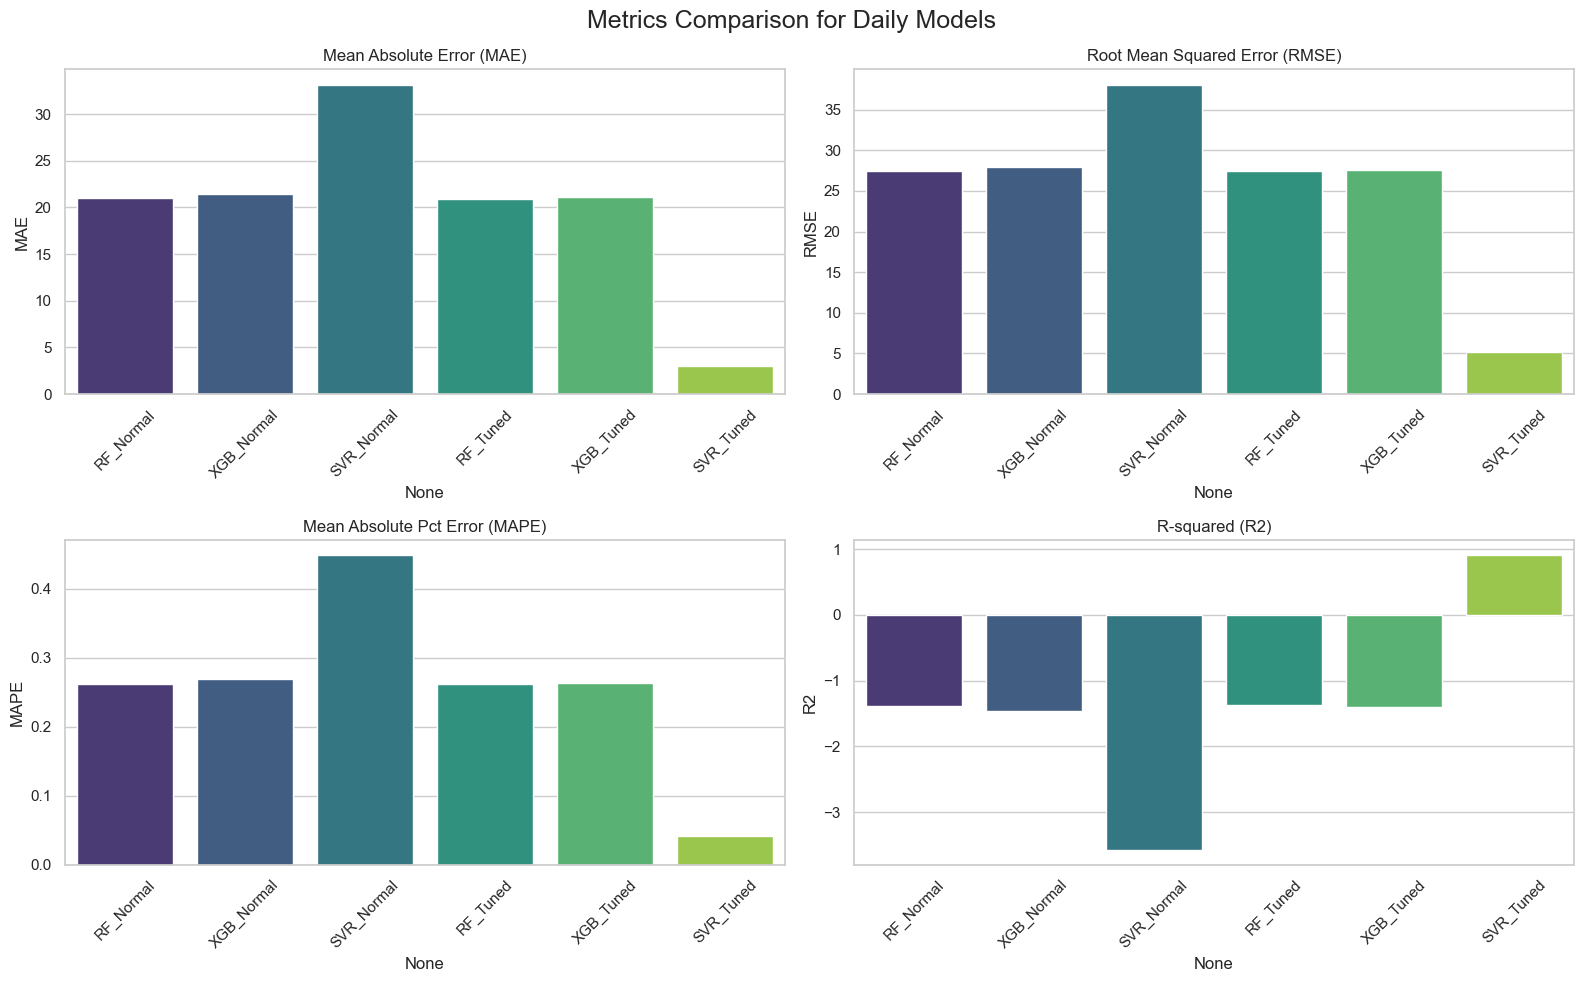

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Metrics Comparison for Daily Models', fontsize=18)

sns.barplot(x=metrics_df_daily.index, y=metrics_df_daily['MAE'], ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Mean Absolute Error (MAE)')
axes[0, 0].tick_params(axis='x', rotation=45)

sns.barplot(x=metrics_df_daily.index, y=metrics_df_daily['RMSE'], ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Root Mean Squared Error (RMSE)')
axes[0, 1].tick_params(axis='x', rotation=45)

sns.barplot(x=metrics_df_daily.index, y=metrics_df_daily['MAPE'], ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Mean Absolute Pct Error (MAPE)')
axes[1, 0].tick_params(axis='x', rotation=45)

sns.barplot(x=metrics_df_daily.index, y=metrics_df_daily['R2'], ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('R-squared (R2)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### **Best Model Selection & 4-Day Projection (Daily)**

The Best Daily Model based on RMSE is: SVR_Tuned


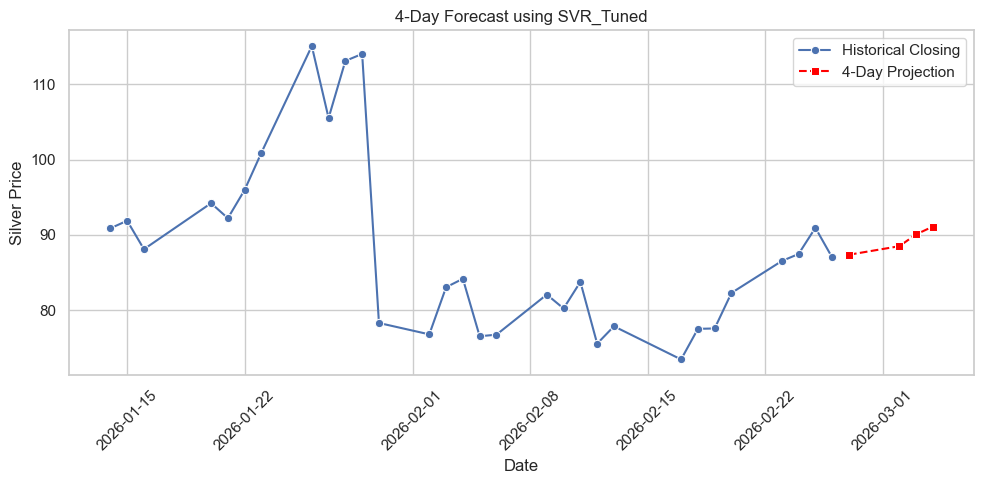

In [ ]:
best_daily_name = metrics_df_daily['RMSE'].idxmin()
best_daily_model = daily_models[best_daily_name]
print(f"The Best Daily Model based on RMSE is: {best_daily_name}")

# Prepare temporal data for recursive projection
last_30_days = daily_data_clean.tail(50).copy()
future_dates = pd.date_range(last_30_days['Date'].iloc[-1] + pd.Timedelta(days=1), periods=4, freq='B')

projections = []

for i in range(4):
    last_row = last_30_days.iloc[-1]

    # Predict the target for the "next" day
    # Convert instance to array
    X_latest = last_row.drop(['Date', 'Target']).values.reshape(1, -1)

    # XGBoost uses specific column shapes without names sometimes
    pred_next_close = best_daily_model.predict(X_latest)[0]
    projections.append(pred_next_close)

    # Create new row simulation
    new_row = last_row.copy()
    new_row['Date'] = future_dates[i]
    new_row['Open'] = last_row['Close']
    new_row['Close'] = pred_next_close
    new_row['High'] = max(new_row['Open'], new_row['Close'])
    new_row['Low'] = min(new_row['Open'], new_row['Close'])

    last_30_days = pd.concat([last_30_days, pd.DataFrame([new_row])], ignore_index=True)

    # Recalculate basic engineered features
    last_30_days.loc[last_30_days.index[-1], 'Return'] = last_30_days['Close'].pct_change().fillna(0).iloc[-1]
    last_30_days.loc[last_30_days.index[-1], 'Range'] = last_30_days['High'].iloc[-1] - last_30_days['Low'].iloc[-1]
    last_30_days.loc[last_30_days.index[-1], 'MA_7'] = last_30_days['Close'].rolling(7, min_periods=1).mean().iloc[-1]
    last_30_days.loc[last_30_days.index[-1], 'MA_14'] = last_30_days['Close'].rolling(14, min_periods=1).mean().iloc[-1]
    last_30_days.loc[last_30_days.index[-1], 'MA_30'] = last_30_days['Close'].rolling(30, min_periods=1).mean().iloc[-1]
    last_30_days.loc[last_30_days.index[-1], 'Volatility_7'] = last_30_days['Close'].rolling(7, min_periods=1).std().fillna(0).iloc[-1]
    last_30_days.loc[last_30_days.index[-1], 'Volatility_30'] = last_30_days['Close'].rolling(30, min_periods=1).std().fillna(0).iloc[-1]
    last_30_days.loc[last_30_days.index[-1], 'Momentum_7'] = (last_30_days['Close'] - last_30_days['Close'].shift(7).fillna(0)).iloc[-1]
    last_30_days.loc[last_30_days.index[-1], 'Lag_1'] = last_30_days['Close'].shift(1).bfill().iloc[-1]
    last_30_days.loc[last_30_days.index[-1], 'Lag_2'] = last_30_days['Close'].shift(2).bfill().iloc[-1]
    last_30_days.loc[last_30_days.index[-1], 'Lag_3'] = last_30_days['Close'].shift(3).bfill().iloc[-1]
    last_30_days.loc[last_30_days.index[-1], 'Lag_7'] = last_30_days['Close'].shift(7).bfill().iloc[-1]

# Plotting the 4-Day Projection
plt.figure(figsize=(10, 5))
historical = daily_data_clean.tail(30)
sns.lineplot(x=historical['Date'], y=historical['Close'], label='Historical Closing', marker='o')
sns.lineplot(x=future_dates, y=projections, label='4-Day Projection', color='red', marker='s', linestyle='dashed')
plt.title(f'4-Day Forecast using {best_daily_name}')
plt.xlabel('Date')
plt.ylabel('Silver Price')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## **2. Monthly Dataset Modeling**

In [ ]:
# Prepare Monthly Data
monthly_data_clean = monthly_data.copy().dropna()
X_monthly = monthly_data_clean.drop(['Date', 'Target'], axis=1)
y_monthly = monthly_data_clean['Target']

# Splitting 80% train, 20% test, sequentially
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_monthly, y_monthly, test_size=0.2, shuffle=False
)

monthly_results = {}
monthly_models = {}

### **Normal Models (Monthly)**

In [ ]:
# 1. Random Forest (Normal)
rf_normal_m = RandomForestRegressor(random_state=42)
rf_normal_m.fit(X_train_m, y_train_m)
monthly_models['RF_Normal'] = rf_normal_m
monthly_results['RF_Normal'] = evaluate_model(y_test_m, rf_normal_m.predict(X_test_m))

# 2. XGBoost (Normal)
xgb_normal_m = XGBRegressor(random_state=42)
xgb_normal_m.fit(X_train_m.values, y_train_m.values)
monthly_models['XGB_Normal'] = xgb_normal_m
monthly_results['XGB_Normal'] = evaluate_model(y_test_m.values, xgb_normal_m.predict(X_test_m.values))

# 3. SVR (Normal) requires scaling
svr_pipeline_normal_m = Pipeline([('scaler', StandardScaler()), ('svr', SVR())])
svr_pipeline_normal_m.fit(X_train_m, y_train_m)
monthly_models['SVR_Normal'] = svr_pipeline_normal_m
monthly_results['SVR_Normal'] = evaluate_model(y_test_m, svr_pipeline_normal_m.predict(X_test_m))

### **Fine-Tuned Models (Monthly)**

In [ ]:
# 1. Random Forest (Tuned)
rf_params_m = {'n_estimators': [50, 100], 'max_depth': [3, 5]}
rf_tuned_m = GridSearchCV(RandomForestRegressor(random_state=42), rf_params_m, cv=3, n_jobs=-1, scoring='neg_root_mean_squared_error')
rf_tuned_m.fit(X_train_m, y_train_m)
monthly_models['RF_Tuned'] = rf_tuned_m.best_estimator_
monthly_results['RF_Tuned'] = evaluate_model(y_test_m, rf_tuned_m.predict(X_test_m))

# 2. XGBoost (Tuned)
xgb_params_m = {'n_estimators': [50, 100], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]}
xgb_tuned_m = GridSearchCV(XGBRegressor(random_state=42), xgb_params_m, cv=3, n_jobs=-1, scoring='neg_root_mean_squared_error')
xgb_tuned_m.fit(X_train_m.values, y_train_m.values)
monthly_models['XGB_Tuned'] = xgb_tuned_m.best_estimator_
monthly_results['XGB_Tuned'] = evaluate_model(y_test_m.values, xgb_tuned_m.predict(X_test_m.values))

# 3. SVR (Tuned)
svr_params_m = {'svr__C': [0.1, 1, 10], 'svr__kernel': ['rbf', 'linear']}
svr_pipeline_tuned_m = GridSearchCV(Pipeline([('scaler', StandardScaler()), ('svr', SVR())]), svr_params_m, cv=3, n_jobs=-1, scoring='neg_root_mean_squared_error')
svr_pipeline_tuned_m.fit(X_train_m, y_train_m)
monthly_models['SVR_Tuned'] = svr_pipeline_tuned_m.best_estimator_
monthly_results['SVR_Tuned'] = evaluate_model(y_test_m, svr_pipeline_tuned_m.predict(X_test_m))

### **Evaluation Metrics Dataframe (Monthly)**

In [ ]:
metrics_df_monthly = pd.DataFrame(monthly_results).T
display(metrics_df_monthly)

,MAE,RMSE,MAPE,R2
RF_Normal,21.307680,22.281300,0.247186,-11.111052
XGB_Normal,14.559643,15.905194,0.167152,-5.171330
SVR_Normal,37.813817,38.352521,0.443299,-34.882992
RF_Tuned,21.307680,22.281300,0.247186,-11.111052
XGB_Tuned,14.698002,16.031945,0.168795,-5.270082
SVR_Tuned,4.352743,5.670168,0.048428,0.215681


### **Plots comparing distinct monthly models**

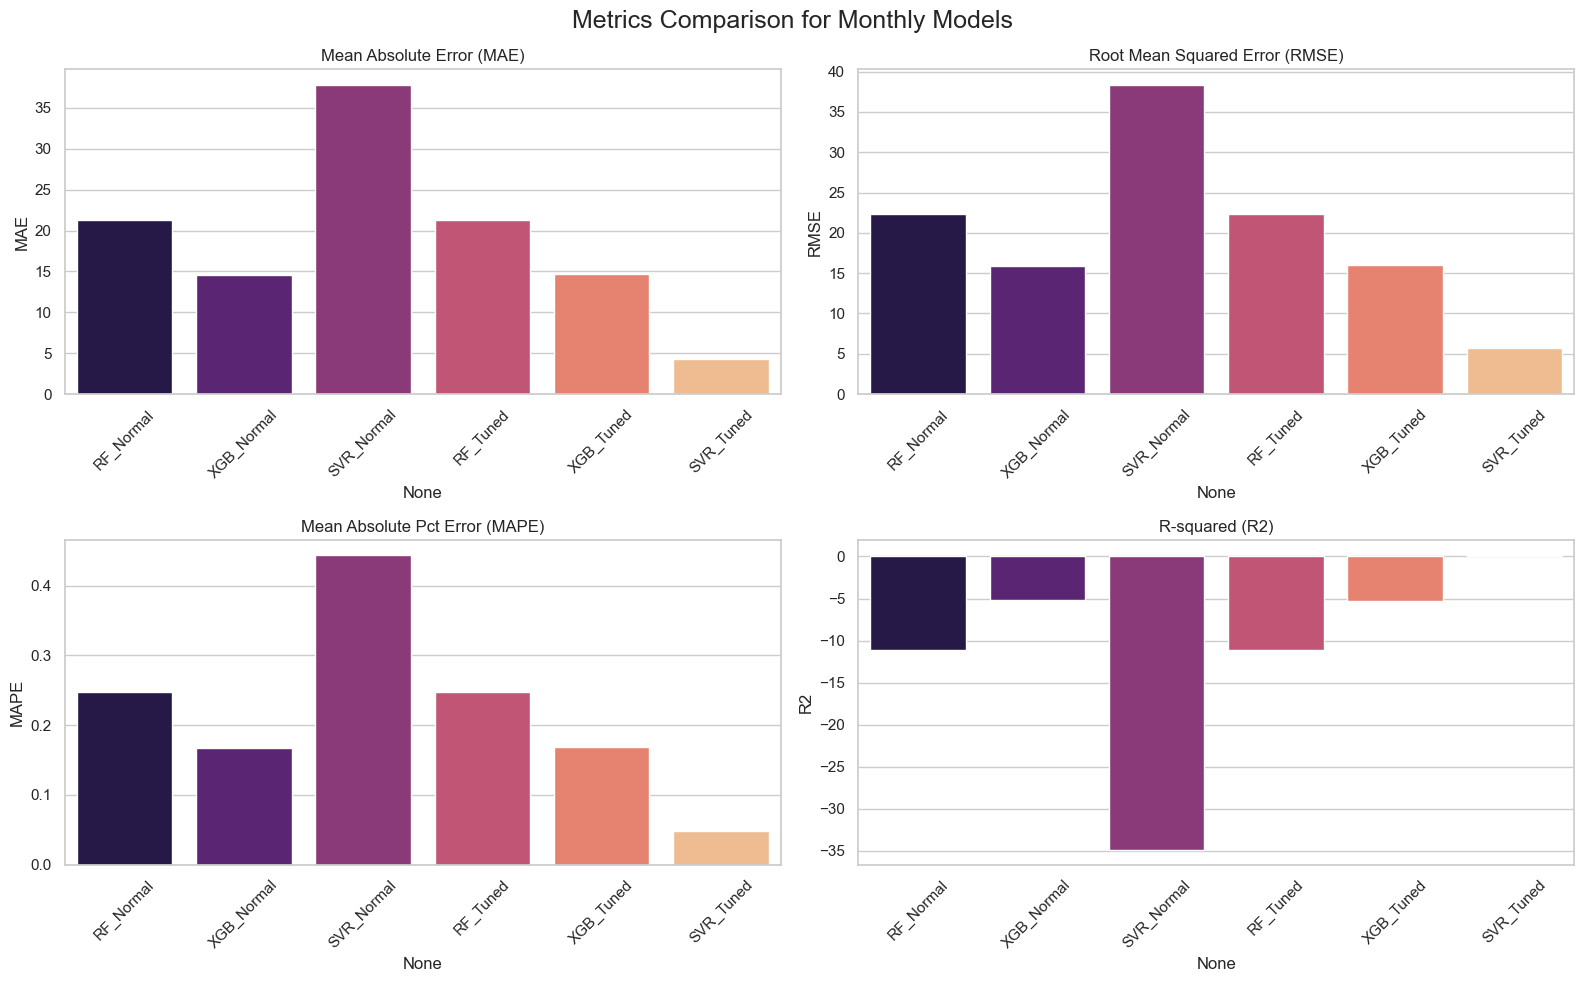

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Metrics Comparison for Monthly Models', fontsize=18)

sns.barplot(x=metrics_df_monthly.index, y=metrics_df_monthly['MAE'], ax=axes[0, 0], palette='magma')
axes[0, 0].set_title('Mean Absolute Error (MAE)')
axes[0, 0].tick_params(axis='x', rotation=45)

sns.barplot(x=metrics_df_monthly.index, y=metrics_df_monthly['RMSE'], ax=axes[0, 1], palette='magma')
axes[0, 1].set_title('Root Mean Squared Error (RMSE)')
axes[0, 1].tick_params(axis='x', rotation=45)

sns.barplot(x=metrics_df_monthly.index, y=metrics_df_monthly['MAPE'], ax=axes[1, 0], palette='magma')
axes[1, 0].set_title('Mean Absolute Pct Error (MAPE)')
axes[1, 0].tick_params(axis='x', rotation=45)

sns.barplot(x=metrics_df_monthly.index, y=metrics_df_monthly['R2'], ax=axes[1, 1], palette='magma')
axes[1, 1].set_title('R-squared (R2)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### **Best Model Selection & 4-Month Projection (Monthly)**

The Best Monthly Model based on RMSE is: SVR_Tuned


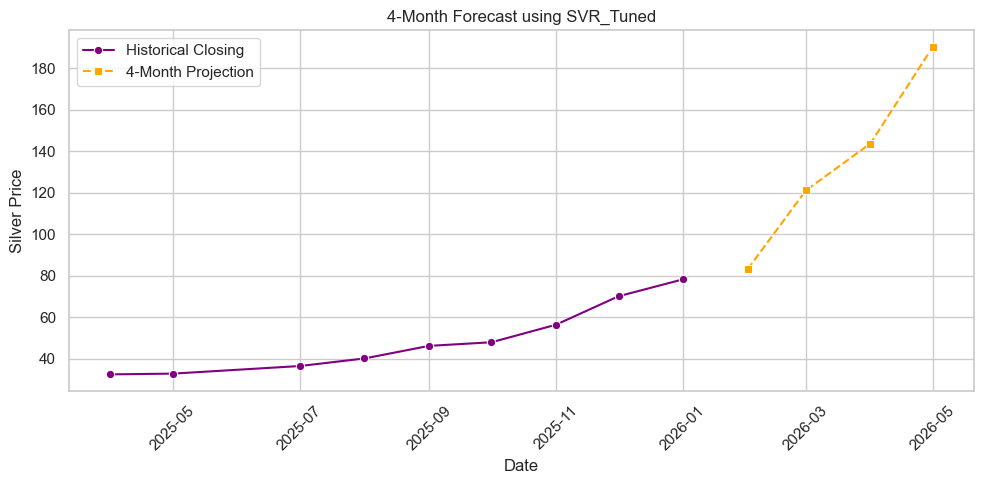

In [ ]:
best_monthly_name = metrics_df_monthly['RMSE'].idxmin()
best_monthly_model = monthly_models[best_monthly_name]
print(f"The Best Monthly Model based on RMSE is: {best_monthly_name}")

# Prepare temporal data for recursive projection
last_12_months = monthly_data_clean.tail(15).copy()
future_dates_m = pd.date_range(last_12_months['Date'].iloc[-1] + pd.DateOffset(months=1), periods=4, freq='MS')

projections_m = []

for i in range(4):
    last_row_m = last_12_months.iloc[-1]

    # Predict the target for the "next" month
    X_latest_m = last_row_m.drop(['Date', 'Target']).values.reshape(1, -1)

    pred_next_close_m = best_monthly_model.predict(X_latest_m)[0]
    projections_m.append(pred_next_close_m)

    # Create new row simulation
    new_row_m = last_row_m.copy()
    new_row_m['Date'] = future_dates_m[i]
    new_row_m['Open'] = last_row_m['Close']
    new_row_m['Close'] = pred_next_close_m
    new_row_m['High'] = max(new_row_m['Open'], new_row_m['Close'])
    new_row_m['Low'] = min(new_row_m['Open'], new_row_m['Close'])

    last_12_months = pd.concat([last_12_months, pd.DataFrame([new_row_m])], ignore_index=True)

    # Recalculate basic engineered features (MA_3, MA_6, MA_12)
    last_12_months.loc[last_12_months.index[-1], 'Return'] = last_12_months['Close'].pct_change().fillna(0).iloc[-1]
    last_12_months.loc[last_12_months.index[-1], 'Range'] = last_12_months['High'].iloc[-1] - last_12_months['Low'].iloc[-1]
    last_12_months.loc[last_12_months.index[-1], 'MA_3'] = last_12_months['Close'].rolling(3, min_periods=1).mean().iloc[-1]
    last_12_months.loc[last_12_months.index[-1], 'MA_6'] = last_12_months['Close'].rolling(6, min_periods=1).mean().iloc[-1]
    last_12_months.loc[last_12_months.index[-1], 'MA_12'] = last_12_months['Close'].rolling(12, min_periods=1).mean().iloc[-1]
    last_12_months.loc[last_12_months.index[-1], 'Volatility_3'] = last_12_months['Close'].rolling(3, min_periods=1).std().fillna(0).iloc[-1]
    last_12_months.loc[last_12_months.index[-1], 'Volatility_6'] = last_12_months['Close'].rolling(6, min_periods=1).std().fillna(0).iloc[-1]
    last_12_months.loc[last_12_months.index[-1], 'Momentum_3'] = (last_12_months['Close'] - last_12_months['Close'].shift(3).fillna(0)).iloc[-1]
    last_12_months.loc[last_12_months.index[-1], 'Lag_1'] = last_12_months['Close'].shift(1).bfill().iloc[-1]
    last_12_months.loc[last_12_months.index[-1], 'Lag_2'] = last_12_months['Close'].shift(2).bfill().iloc[-1]
    last_12_months.loc[last_12_months.index[-1], 'Lag_3'] = last_12_months['Close'].shift(3).bfill().iloc[-1]

# Plotting the 4-Month Projection
plt.figure(figsize=(10, 5))
historical_m = monthly_data_clean.tail(15)
sns.lineplot(x=historical_m['Date'], y=historical_m['Close'], label='Historical Closing', marker='o', color='purple')
sns.lineplot(x=future_dates_m, y=projections_m, label='4-Month Projection', color='orange', marker='s', linestyle='dashed')
plt.title(f'4-Month Forecast using {best_monthly_name}')
plt.xlabel('Date')
plt.ylabel('Silver Price')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()